<a href="https://colab.research.google.com/github/Henry-Gbriel/Curso-USP-An-lise-de-Dados---Esalq/blob/main/Analise_Correspondencia_ACS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
pip install prince

In [63]:
pip install scipy

In [64]:
import pandas as pd # manipulação DataFrame
import prince # Faz o teste de associação estatística
from scipy.stats import chi2_contingency # Faz CA e MCA via SMD
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

In [65]:
perfil = pd.read_excel('/content/Perfil Aplicaç╞o.xlsx')

print(perfil)

      Estudante       Perfil Tipo de Aplicação
0      Gabriela  Conservador          Poupança
1   Luiz Felipe  Conservador          Poupança
2      Patrícia  Conservador          Poupança
3       Gustavo  Conservador          Poupança
4       Letícia  Conservador          Poupança
..          ...          ...               ...
95       Sheila    Agressivo             Ações
96        Pedro    Agressivo             Ações
97      Horácio    Agressivo             Ações
98      Leandro    Agressivo             Ações
99       Estela    Agressivo             Ações

[100 rows x 3 columns]


In [66]:
perfil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Estudante          100 non-null    object
 1   Perfil             100 non-null    object
 2   Tipo de Aplicação  100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB


In [67]:
perfil.describe()

,Estudante,Perfil,Tipo de Aplicação
count,100,100,100
unique,100,3,3
top,Gabriela,Agressivo,Ações
freq,1,58,45


In [68]:
perfil.head(30)

,Estudante,Perfil,Tipo de Aplicação
0,Gabriela,Conservador,Poupança
1,Luiz Felipe,Conservador,Poupança
2,Patrícia,Conservador,Poupança
3,Gustavo,Conservador,Poupança
4,Letícia,Conservador,Poupança
5,Ovídio,Conservador,Poupança
6,Leonor,Conservador,Poupança
7,Dalila,Conservador,Poupança
8,Antônio,Conservador,CDB
9,Júlia,Conservador,CDB


In [69]:
#deixando somente as variaveis uteis

tabela = pd.crosstab(perfil['Perfil'], perfil['Tipo de Aplicação'])

In [70]:
print(tabela)

Tipo de Aplicação  Ações  CDB  Poupança
Perfil                                 
Agressivo             36   20         2
Conservador            5    4         8
Moderado               4   16         5


In [71]:
#Teste do QUI-QUADRADO

chi2, pvalor, df, freq_esp = chi2_contingency(tabela)

print(f"estatística qui²: {chi2}") # estatística qui²
print(f"p-valor da estatística: {pvalor}") # p-valor da estatística
print(f"graus de liberdade: {df}") # graus de liberdade

estatística qui²: 31.764164976335362
p-valor da estatística: 2.137594051381398e-06
graus de liberdade: 4


In [72]:
ca = prince.CA() #Anacor

In [73]:
# Renomeando as linhas e colunas do dataframe

tabela.columns.rename('Investimento', inplace=True)
tabela.index.rename('Perfil', inplace=True)

print(tabela)

Investimento  Ações  CDB  Poupança
Perfil                            
Agressivo        36   20         2
Conservador       5    4         8
Moderado          4   16         5


In [74]:
a = ca.fit(tabela)

In [75]:
#Obtendo as coordenadas em linha e coluna

print(ca.row_coordinates(tabela), "\n")
print(ca.column_coordinates(tabela))


                    0         1
Perfil                         
Agressivo   -0.396262 -0.065513
Conservador  0.786648 -0.433800
Moderado     0.384408  0.446974 

                     0         1
Investimento                    
Ações        -0.404692 -0.209522
CDB           0.071019  0.353291
Poupança      1.024690 -0.313542


In [76]:
#%% Obtendo as coordenadas em linha e coluna

print(ca.row_coordinates(tabela), "\n")
print(ca.column_coordinates(tabela))

                    0         1
Perfil                         
Agressivo   -0.396262 -0.065513
Conservador  0.786648 -0.433800
Moderado     0.384408  0.446974 

                     0         1
Investimento                    
Ações        -0.404692 -0.209522
CDB           0.071019  0.353291
Poupança      1.024690 -0.313542


In [77]:
#%% Obtendo os eigenvalues

print(ca.eigenvalues_)

[0.23321487 0.08442678]


In [78]:
#%% Obtendo as coordenadas em linha e coluna

print("Coordenadas das Linhas:")
print(ca.row_coordinates(tabela), "\n")

print("Coordenadas das Colunas:")
print(ca.column_coordinates(tabela))


#%% Obtendo os eigenvalues

eigenvalues = ca.eigenvalues_
print("\nEigenvalues:")
print(eigenvalues)


#%% Obtendo a inércia principal total

# A inércia total é a soma dos eigenvalues
total_inertia = eigenvalues.sum()
print("\nInércia principal total:")
print(total_inertia)


#%% Inércia explicada por dimensão

# Percentual da inércia explicada por cada dimensão
explained_inertia = eigenvalues / total_inertia
print("\nInércia explicada por dimensão:")
print(explained_inertia)


#%% Massas em linhas

# Massa = proporção do total da linha sobre o total geral
row_masses = tabela.sum(axis=1) / tabela.values.sum()
print("\nMassas em linhas:")
print(row_masses)


#%% Massas em colunas

# Massa = proporção do total da coluna sobre o total geral
col_masses = tabela.sum(axis=0) / tabela.values.sum()
print("\nMassas em colunas:")
print(col_masses)


#%% Conferência opcional: Inércia via Qui²

from scipy.stats import chi2_contingency

chi2, pvalor, df, freq_esp = chi2_contingency(tabela)
N = tabela.values.sum()

print("\nInércia total via Qui² (chi² / N):")
print(chi2 / N)

Coordenadas das Linhas:
                    0         1
Perfil                         
Agressivo   -0.396262 -0.065513
Conservador  0.786648 -0.433800
Moderado     0.384408  0.446974 

Coordenadas das Colunas:
                     0         1
Investimento                    
Ações        -0.404692 -0.209522
CDB           0.071019  0.353291
Poupança      1.024690 -0.313542

Eigenvalues:
[0.23321487 0.08442678]

Inércia principal total:
0.3176416497633535

Inércia explicada por dimensão:
[0.73420747 0.26579253]

Massas em linhas:
Perfil
Agressivo      0.58
Conservador    0.17
Moderado       0.25
dtype: float64

Massas em colunas:
Investimento
Ações       0.45
CDB         0.40
Poupança    0.15
dtype: float64

Inércia total via Qui² (chi² / N):
0.31764164976335363


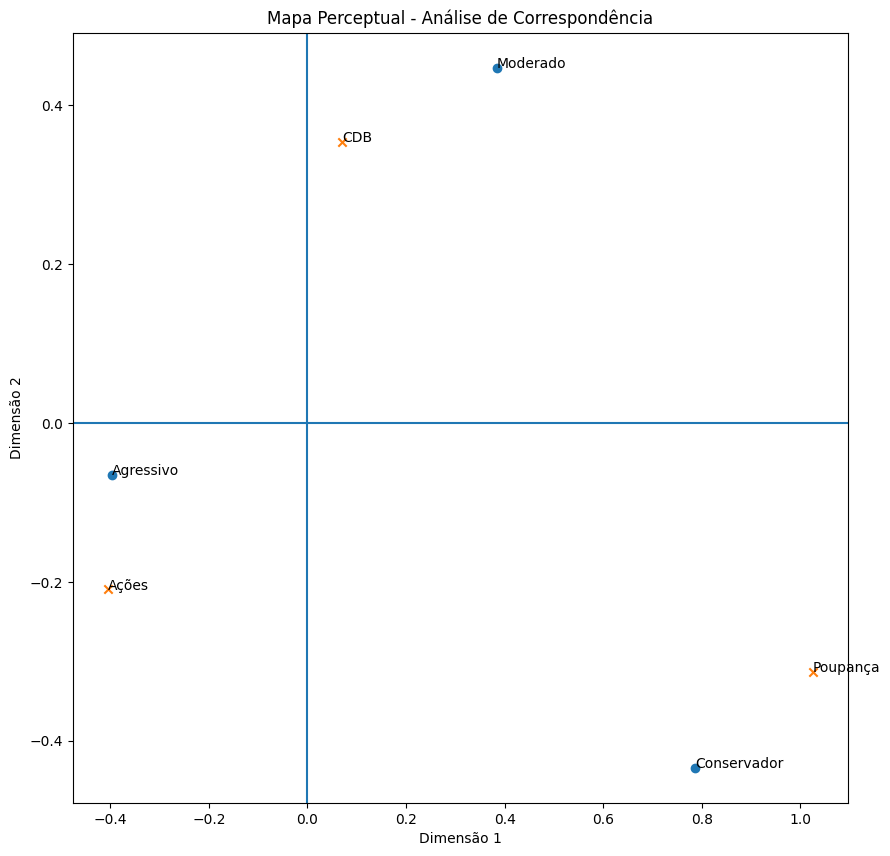

In [79]:
# Coordenadas
row_coords = ca.row_coordinates(tabela)
col_coords = ca.column_coordinates(tabela)

plt.figure(figsize=(10,10))

# Plot linhas (perfis)
plt.scatter(row_coords[0], row_coords[1])
for i, txt in enumerate(row_coords.index):
    plt.text(row_coords.iloc[i,0],
             row_coords.iloc[i,1],
             txt)

# Plot colunas (aplicações)
plt.scatter(col_coords[0], col_coords[1], marker='x')
for i, txt in enumerate(col_coords.index):
    plt.text(col_coords.iloc[i,0],
             col_coords.iloc[i,1],
             txt)

plt.axhline(0)
plt.axvline(0)

plt.xlabel("Dimensão 1")
plt.ylabel("Dimensão 2")
plt.title("Mapa Perceptual - Análise de Correspondência")

plt.show()

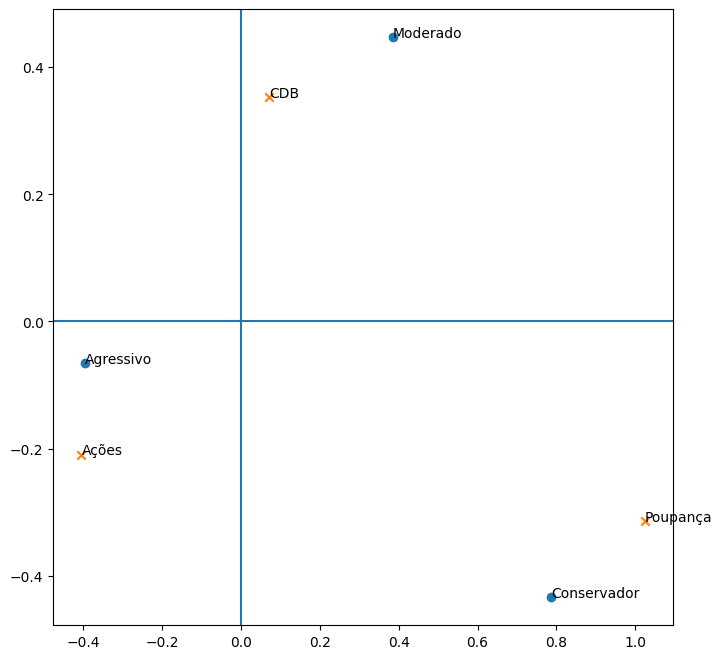

In [81]:
row_coords = ca.row_coordinates(tabela)
col_coords = ca.column_coordinates(tabela)

plt.figure(figsize=(8,8))

plt.scatter(row_coords.iloc[:,0], row_coords.iloc[:,1])
for i, txt in enumerate(row_coords.index):
    plt.text(row_coords.iloc[i,0], row_coords.iloc[i,1], txt)

plt.scatter(col_coords.iloc[:,0], col_coords.iloc[:,1], marker='x')
for i, txt in enumerate(col_coords.index):
    plt.text(col_coords.iloc[i,0], col_coords.iloc[i,1], txt)

plt.axhline(0)
plt.axvline(0)

plt.show()